**Cisplatin FF Parameterized via FUERZA Estimation & Subsequent Gradient Optimization**

Cisplatin toy example

In [1]:
import os
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import sys
from matplotlib import animation, rc
from IPython.display import HTML, Image
import seaborn
import pickle
import pandas as pd
from numpy import copy
from scipy import stats
import itertools
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
from sklearn.metrics import r2_score
from multipledispatch import dispatch

seaborn.set_theme(style="whitegrid")

seaborn.set_theme()
seaborn.set_context("paper")
seaborn.set_style('white')
#seaborn.set_style("ticks")
zesty = ['#F5793A', '#A95AA1', '#85C0F9', '#0F2080']
palette = itertools.cycle(seaborn.color_palette(palette=zesty))

src_dir = os.path.abspath("/home/mmfarrugia/repos/q2mm")
sys.path.append(src_dir)
#sys.path.append("/home/mfarrugi/repos/q2mm/rh-hybrid/schrodinger.ve/lib/python3.11/site-packages/q2mm-0.0.0-py3.11.egg")


from tools.ff_plotting import *

In [2]:
bond_cols = ["param_type", "atom1", "atom2", "Equilibrium Value", "Force Constant", "Dipole Moment", "FF"]
angle_cols = ["param_type", "atom1", "atom2", "atom3", "Equilibrium Value", "Force Constant", "FF"]
score_cols = ["Label", "Weight", "Reference", "Calculated", "Score", "FF"]
skiprows=[0, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391]
bond_rows = np.arange(1860, 1863)
angle_rows = np.arange(1863, 1869)
bond_label_list = ['N3.PT', 'N3-H3', 'PT-CL']
angle_label_list = ['trans\nN3.PT-CL', 'cis\nN3.PT-CL', 'N3.PT.N3', 'CL-PT-CL', 'H3-N3.PT', 'H3-N3-H3']

base_direc = os.getcwd()

# Scores

## unoptimized data
static_score = 260
static_scores = pd.read_csv('static/eig_static.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='Approxn: '+str(static_score))
fuerza_score = 590.5287
fuerza_scores = pd.read_csv('fuerza/eig_start.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FUERZA: '+str(fuerza_score))
gamma_fuerza_score = 247.7877
gamma_fuerza_scores = pd.read_csv('gamma_fuerza/eig_gamma.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=r'$\mathit{\gamma}$-FUERZA: '+str(gamma_fuerza_score))
ffuerza_score = 107.7652
ffuerza_scores = pd.read_csv('frankenfuerza/eig_start.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='QFUERZA: '+str(ffuerza_score))

## optimized data
normal_grad_score = 1.7479
normal_grad_scores = pd.read_csv('static/score.static.grad.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='Approxn-GRAD: '+str(normal_grad_score))
fuerza_grad_score = 1.747901
fuerza_grad_scores = pd.read_csv('fuerza/score.eig.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FUERZA-GRAD: '+str(fuerza_grad_score))
gamma_fuerza_grad_score = 1.7482
gamma_fuerza_grad_scores = pd.read_csv('gamma_fuerza/score.gamma.grad.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=r'$\mathit{\gamma}$-FUERZA-GRAD: '+str(gamma_fuerza_grad_score))
ffuerza_grad_score = 1.7479001
ffuerza_grad_scores = pd.read_csv('frankenfuerza/score.eig.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='QFUERZA-GRAD: '+str(ffuerza_grad_score))

# Bonds

## unoptimized
bond_normal = pd.read_csv('static/mm3.static.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=static_score)
angle_normal = pd.read_csv('static/mm3.static.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=static_score)
bond_fuerza, angle_fuerza, param_fuerza = get_ff_params(base_direc, ['fuerza'], 'cisplatin_fuerza.fld', [fuerza_score], bond_rows, angle_rows, 'FUERZA')
bond_fuerza = bond_fuerza[0]
angle_fuerza = angle_fuerza[0]
bond_gamma_fuerza, gamma_angle_fuerza, param_gamma_fuerza = get_ff_params(base_direc, ['gamma_fuerza'], 'cisplatin_gamma_fuerza.fld', [gamma_fuerza_score], bond_rows, angle_rows, r'$\mathit{\gamma}$-FUERZA')
gamma_angle_fuerza = gamma_angle_fuerza[0]
bond_ffuerza, angle_ffuerza, param_ffuerza = get_ff_params('frankenfuerza', [''], 'frankenfuerza_H.fld', [ffuerza_score], bond_rows, angle_rows, 'QFUERZA')
angle_ffuerza = angle_ffuerza[0]

## optimized
bond_normal_grad = pd.read_csv('static/mm3.static.grad.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=normal_grad_score)
angle_normal_grad = pd.read_csv('static/mm3.static.grad.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=normal_grad_score)
bond_fuerza_grad = pd.read_csv('fuerza/mm3.eig.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=fuerza_grad_score)
angle_fuerza_grad = pd.read_csv('fuerza/mm3.eig.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=fuerza_grad_score)
gamma_bond_fuerza_grad = pd.read_csv('gamma_fuerza/mm3.gamma.grad.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=gamma_fuerza_score)
gamma_angle_fuerza_grad = pd.read_csv('gamma_fuerza/mm3.gamma.grad.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=gamma_fuerza_score)
bond_ffuerza_grad = pd.read_csv('frankenfuerza/mm3.eig.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=ffuerza_grad_score)
angle_ffuerza_grad = pd.read_csv('frankenfuerza/mm3.eig.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=ffuerza_grad_score)

bonds = [bond_fuerza, bond_fuerza, bond_fuerza, bond_normal_grad, bond_fuerza_grad, gamma_bond_fuerza_grad, bond_ffuerza_grad]
angles = [angle_fuerza, gamma_angle_fuerza, angle_ffuerza, angle_normal_grad, angle_fuerza_grad, angle_ffuerza_grad, gamma_angle_fuerza_grad]
eigenmatrix_scores = [static_scores, fuerza_scores, gamma_fuerza_scores, ffuerza_scores, normal_grad_scores, fuerza_grad_scores, gamma_fuerza_grad_scores, ffuerza_grad_scores]
score_sums = ['Approxn: '+'{0:.3f}'.format(static_score), 'FUERZA: '+'{0:.3f}'.format(fuerza_score), r'$\mathit{\gamma}$-FUERZA: '+'{0:.3f}'.format(gamma_fuerza_score), 'QFUERZA: '+'{0:.3f}'.format(ffuerza_score), 'Approxn-GRAD: '+'{0:.3f}'.format(normal_grad_score), 'FUERZA-GRAD: '+'{0:.3f}'.format(fuerza_grad_score), r'$\mathit{\gamma}$-FUERZA-GRAD: '+'{0:.3f}'.format(gamma_fuerza_grad_score), 'QFUERZA-GRAD: '+'{0:.3f}'.format(ffuerza_grad_score)]

In [3]:
for i in range(len(bonds)):
    bonds[i] = bonds[i].assign(Parameter=bond_label_list) 
    angles[i] = angles[i].assign(Parameter=angle_label_list)

In [4]:
def style_per_plot_legends(axes:list):# -> list:
    for ax in axes:
        ax.legend(bbox_to_anchor=(0.5, -0.35), loc='lower center', fancybox=True, framealpha=0.5, ncol=2, columnspacing=1., handletextpad=0.)
    return axes

@dispatch(list)
def style_fig_legend(axes:list):
    for ax in axes:
        ax = ax.legend(bbox_to_anchor=(1.5, 1), fancybox=True, framealpha=0.5)
    return axes

@dispatch(plt.Axes)
def style_fig_legend(axes:plt.Axes):
    ax = ax.legend(bbox_to_anchor=(1.5, 1), fancybox=True, framealpha=0.5)
    return ax

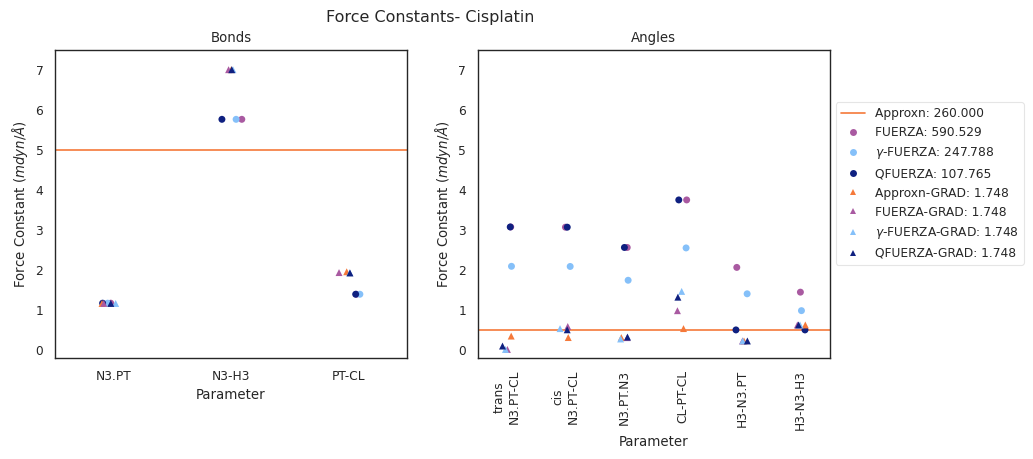

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Bonds'}, xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>,
        <Axes: title={'center': 'Angles'}, xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>],
       dtype=object))

In [5]:
def plot_ff_params_v_staticc(bonds:list, angles:list, final_scores:list, title:str='', bond_labels=None, angles_labels=None, estimate_score=None):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle('Force Constants'+title)
    ax[0].set_title('Bonds')
    ax[1].set_title('Angles')

    colors_pick = seaborn.color_palette(palette=zesty)
    # palette = itertools.cycle(seaborn.color_palette(palette=zesty))
    # palette_opt = itertools.cycle(seaborn.color_palette(palette=zesty))
    palette = itertools.cycle(colors_pick)
    edges = itertools.cycle(zesty2_palette)
    
    color=next(palette)
    edge=next(edges)
    estimate_label = estimate_score if estimate_score is not None else 'Estimate'
    ax[0].axhline(5, color=color, label=estimate_label)
    ax[1].axhline(0.5, color=color, label=estimate_label)


    if bond_labels is None:
        bond_labels = bonds[0][['atom1', 'atom2', 'param_type']].values
        bond_labels = [str(bl) for bl in bond_labels]
    if angles_labels is None:
        angles_labels = angles[0][['atom1', 'atom2', 'atom3', 'param_type']].values
        angles_labels = [str(al) for al in angles_labels]

    bond_unopt, angle_unopt, bond_opt, angle_opt = filter_params_by_type_opt(bonds, angles, final_scores)
    seaborn.stripplot(data=bond_unopt, x="Parameter", y="Force Constant", ax=ax[0], hue="FF", jitter=True, palette=palette)
    seaborn.stripplot(data=angle_unopt, x="Parameter", y="Force Constant", ax=ax[1], hue="FF", jitter=True, palette=itertools.cycle(colors_pick[1:]))
    seaborn.stripplot(data=bond_opt, x="Parameter", y="Force Constant", ax=ax[0], hue="FF", jitter=True, palette=itertools.cycle(colors_pick), marker='^')
    seaborn.stripplot(data=angle_opt, x="Parameter", y="Force Constant", ax=ax[1], hue="FF", jitter=True, palette=itertools.cycle(colors_pick), marker='^')


    plt.xticks(rotation=90)
    ax[0].legend_.remove()
    ax[1].legend(bbox_to_anchor=(1.0, 0.85), fancybox=True, framealpha=0.5)
    ax[0].set_ylabel(r'Force Constant ($mdyn/\AA$)')
    ax[1].set_ylabel(r'Force Constant ($mdyn/\AA$)')
    ax[0].set_ylim(top=7.5, bottom=-0.2)
    ax[1].set_ylim(top=7.5, bottom=-0.2)
    plt.show()
    return fig, ax


plot_ff_params_v_staticc(bonds, angles, score_sums[1:], bond_labels=bond_label_list, angles_labels=angle_label_list, estimate_score=score_sums[0], title='- Cisplatin')

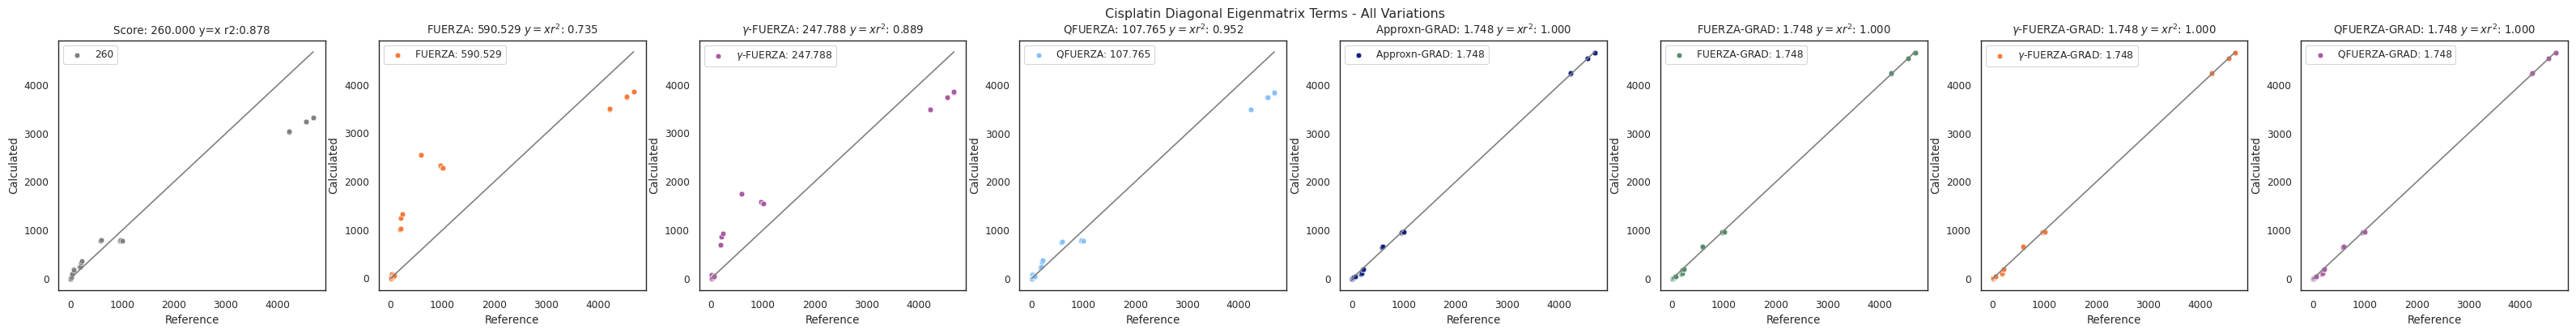

In [6]:
linear_fit_diag_scores(static_scores, static_score, eigenmatrix_scores[1:], score_sums[1:], ' Cisplatin Diagonal Eigenmatrix Terms - All Variations')

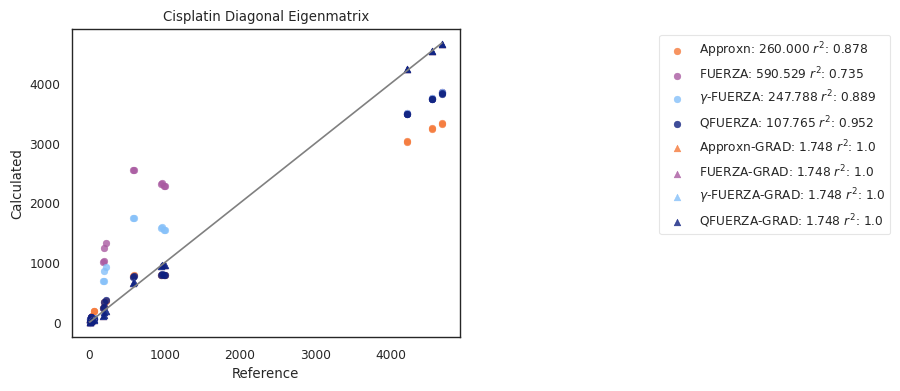

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(5,4))
ax.set_title('Cisplatin Diagonal Eigenmatrix')
palette = itertools.cycle(seaborn.color_palette(palette=zesty))
palette_opt = itertools.cycle(seaborn.color_palette(palette=zesty))


for eigenmatrix, score in zip(eigenmatrix_scores, score_sums):
    diag = eigenmatrix.loc[eigenmatrix['Reference'] != 0.0000]
    diag = diag.loc[diag['Weight'] != 0.0000]
    #slope, intercept, r2, pv, se = stats.linregress(diag_start['Reference'], diag_start['Calculated'])
    r2_ = r2_score(diag['Reference'], diag['Calculated'])
    if any(opt_flag in score for opt_flag in ['Opt', 'OPT', 'GRAD', 'HO']):
        marker="^"
        color = next(palette_opt)
    else:
        marker = "o"
        color = next(palette)
    seaborn.scatterplot(data=diag, y='Calculated', x='Reference', color=color, edgecolor=color, label=score + r' $r^{2}$: '+str(np.round(r2_, decimals=3)), ax=ax, marker=marker, alpha = 0.8)

seaborn.lineplot(data=diag, x='Reference', y='Reference', color='gray', ax=ax)
ax = ax.legend(bbox_to_anchor=(1.5, 1), fancybox=True, framealpha=0.5)

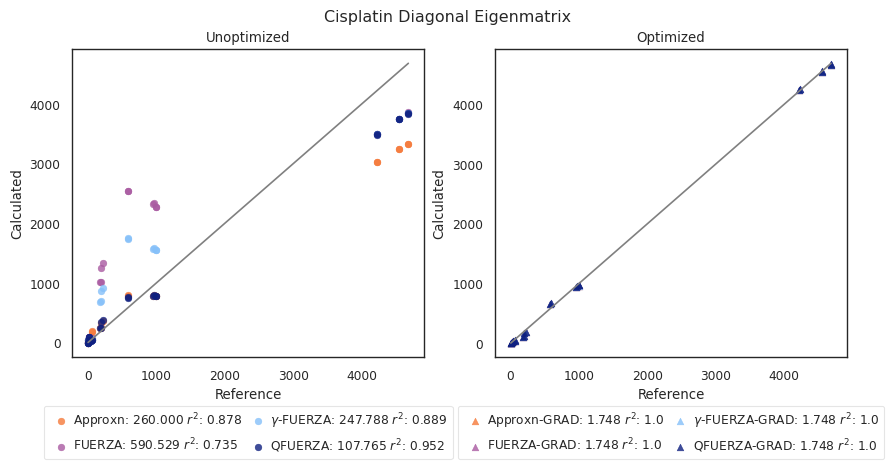

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))
fig.suptitle('Cisplatin Diagonal Eigenmatrix')
palette = itertools.cycle(seaborn.color_palette(palette=zesty))
palette_opt = itertools.cycle(seaborn.color_palette(palette=zesty))

r2_scores = []
r2_score_labels = []

for eigenmatrix, score in zip(eigenmatrix_scores, score_sums):
    diag = eigenmatrix.loc[eigenmatrix['Reference'] != 0.0000]
    diag = diag.loc[diag['Weight'] != 0.0000]
    #slope, intercept, r2, pv, se = stats.linregress(diag_start['Reference'], diag_start['Calculated'])
    r2_ = r2_score(diag['Reference'], diag['Calculated'])
    r2_scores.append(r2_)
    if any(opt_flag in score for opt_flag in ['Opt', 'OPT', 'GRAD', 'HO']):
        marker="^"
        color = next(palette_opt)
        axis=1
    else:
        marker = "o"
        color = next(palette)
        axis=0
    seaborn.scatterplot(data=diag, y='Calculated', x='Reference', color=color, edgecolor=color, label=score + r' $r^{2}$: '+str(np.round(r2_, decimals=3)), ax=ax[axis], marker=marker, alpha = 0.8)
    r2_score_labels.append(score + r' $r^{2}$: '+str(np.round(r2_, decimals=3)))

seaborn.lineplot(data=diag, x='Reference', y='Reference', color='gray', ax=ax[0])
seaborn.lineplot(data=diag, x='Reference', y='Reference', color='gray', ax=ax[1])
ax[0].set_title('Unoptimized')
ax[1].set_title('Optimized')
ax[0].legend(bbox_to_anchor=(0.5, -0.35), loc='lower center', fancybox=True, framealpha=0.5, ncol=2, columnspacing=0.3, handletextpad=0.)
ax[1].legend(bbox_to_anchor=(0.5, -0.35), loc='lower center', fancybox=True, framealpha=0.5, ncol=2, columnspacing=0.3, handletextpad=0.)

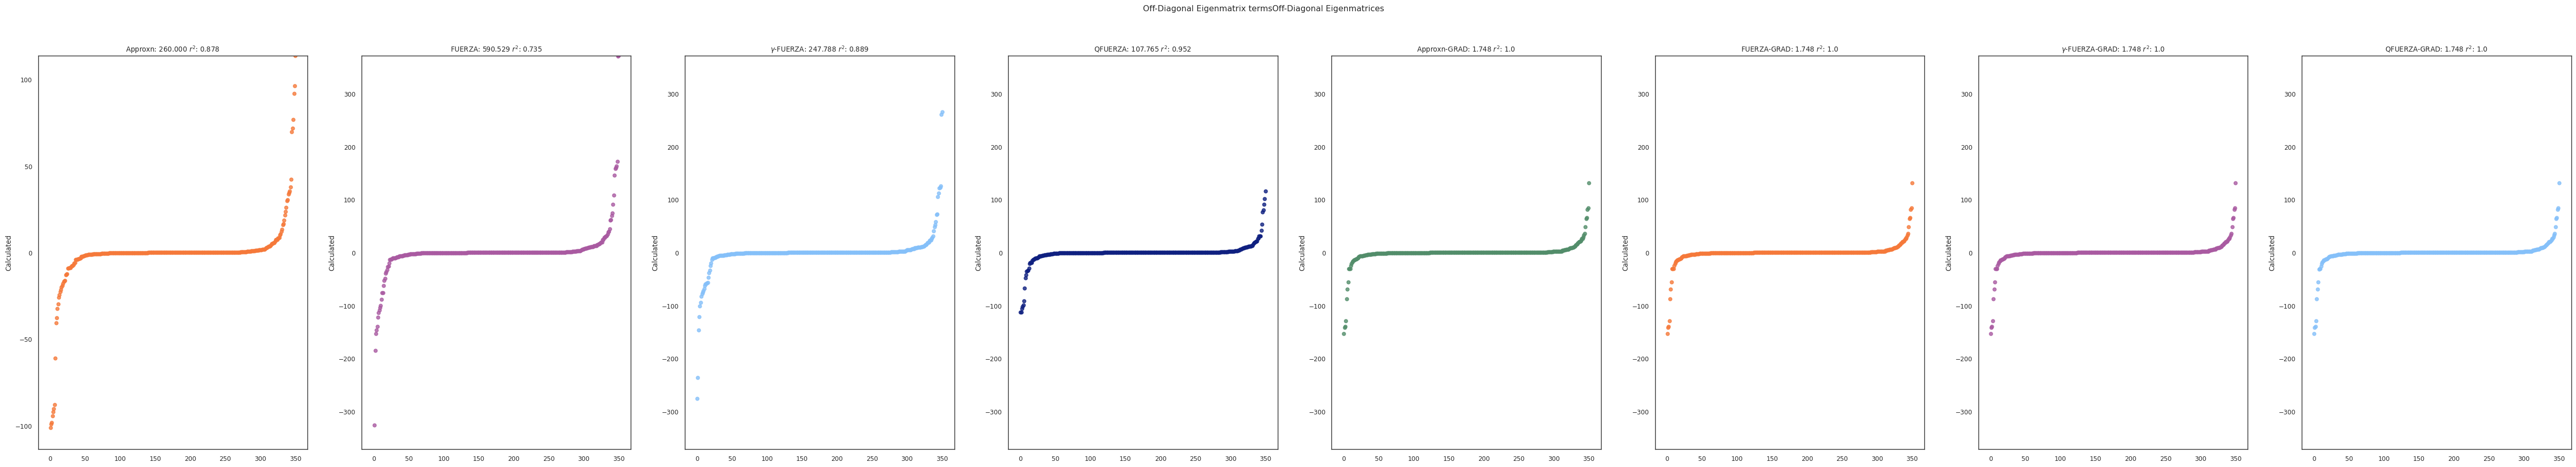

In [9]:
plot_off_diag_scatter(eigenmatrix_scores, r2_score_labels, 'Off-Diagonal Eigenmatrices')

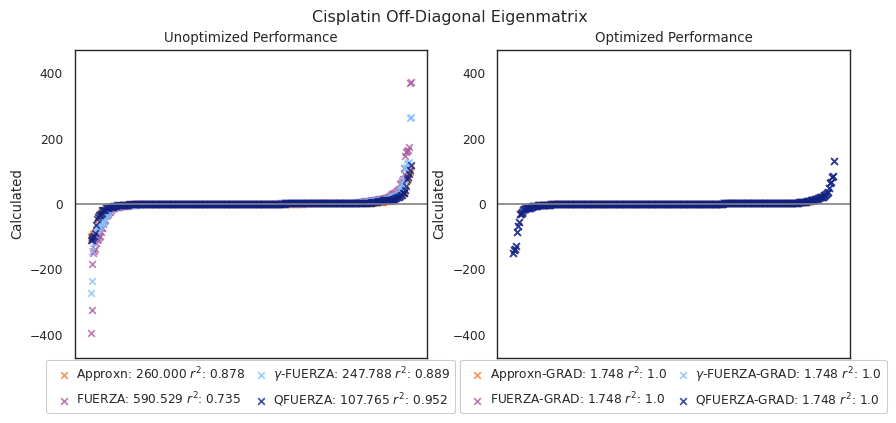

In [10]:
def off_diag_scatter(score_matrices:list, total_scores:list, title:str=''):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle('Cisplatin Off-Diagonal Eigenmatrix'+title)
    palette = itertools.cycle(zesty_palette)
    palette_opt = itertools.cycle(zesty_palette)
    max_y = 0.

    for i, run in enumerate(score_matrices):
        off_diag = run.loc[run['Reference'] == 0.0000]
        off_diag = off_diag.loc[off_diag['Weight'] != 0.0000]
        off_diag = off_diag.sort_values(by='Calculated', ignore_index=True)

        if any(opt_flag in total_scores[i] for opt_flag in ['Opt', 'OPT', 'GRAD', 'HO']):
            color = next(palette_opt)
            axis=1
        else:
            color = next(palette)
            axis=0
        
        seaborn.regplot(data=off_diag, x=off_diag.index, label=r2_score_labels[i], y='Calculated', marker='x', fit_reg=False, ax=ax[axis], color=color)
        max_y = max(max_y, max(off_diag['Calculated']))

    max_y = max_y + 100
    ax[0].set_ylim(top=max_y, bottom=-max_y)
    ax[1].set_ylim(top=max_y, bottom=-max_y)
    ax[0].set_title('Unoptimized Performance')
    ax[1].set_title('Optimized Performance')
    ax[0].legend(bbox_to_anchor=(0.5, -0.2), loc='lower center', fancybox=True, framealpha=1, ncol=2, columnspacing=0.3, handletextpad=0.)
    ax[1].legend(bbox_to_anchor=(0.5, -0.2), loc='lower center', fancybox=True, framealpha=1, ncol=2, columnspacing=0.3, handletextpad=0.)
    ax[0].axhline(y=0, color='gray')
    ax[1].axhline(y=0, color='gray')
    plt.show()

off_diag_scatter(eigenmatrix_scores, score_sums)

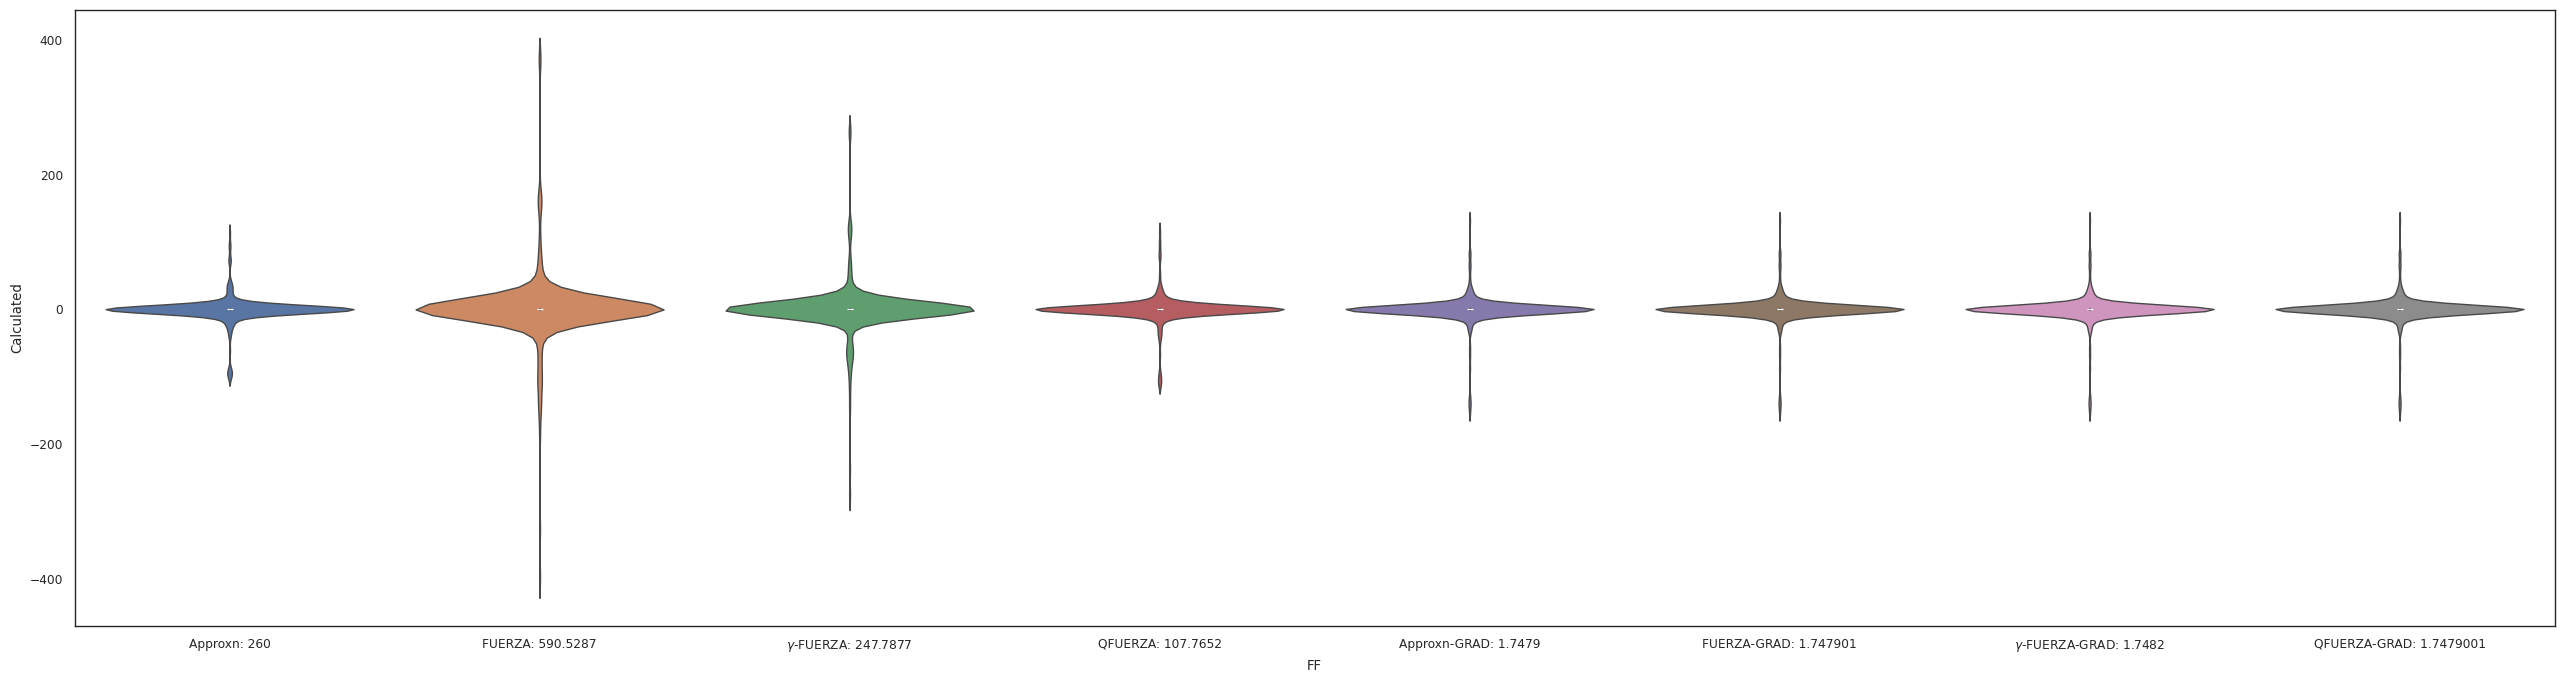

In [11]:
plot_off_diag_violin(static_scores, static_score, eigenmatrix_scores[1:], score_sums[1:])

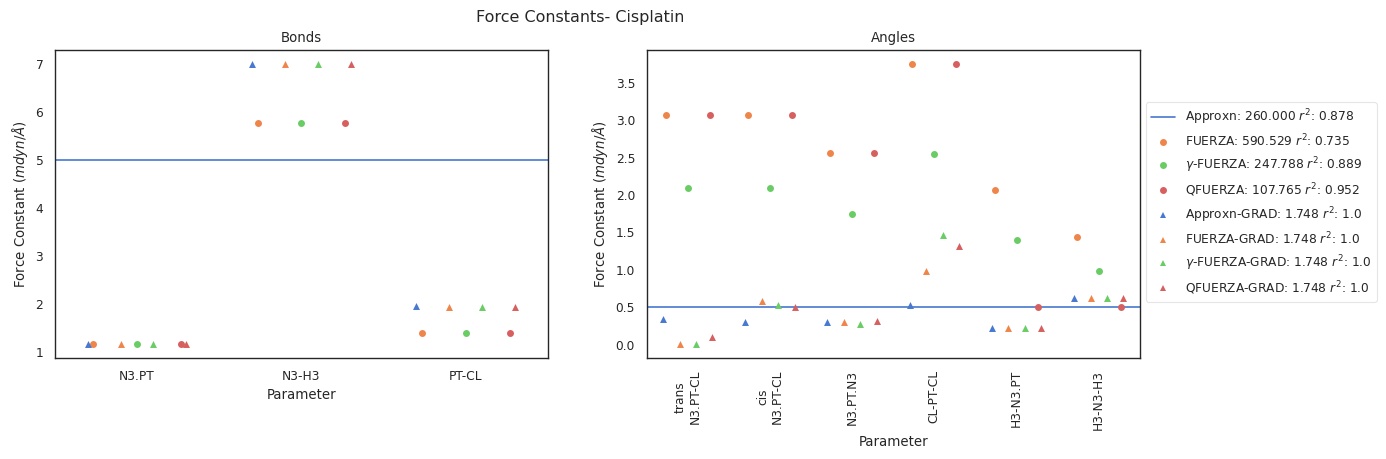

(<Figure size 1400x400 with 2 Axes>,
 array([<Axes: title={'center': 'Bonds'}, xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>,
        <Axes: title={'center': 'Angles'}, xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>],
       dtype=object))

In [12]:
plot_ff_params_v_static(bonds, angles, r2_score_labels[1:], bond_labels=bond_label_list, angles_labels=angle_label_list, estimate_score=r2_score_labels[0], title='- Cisplatin')